<a href="https://colab.research.google.com/github/srinivasjvv25/AI-Travel-Planner/blob/main/Copy3_of_fl_sleep_apnea_cnn_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installs

In [39]:
!pip install flwr[simulation]
!pip install wfdb

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
#dupe
import torch
print(torch.__version__)

2.10.0+cpu


In [42]:
# !pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu

In [43]:
# !pip show torch

In [44]:
import flwr as fl

In [45]:
#!unzip -q '/content/drive/MyDrive/datum.zip'

In [46]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import time
import seaborn as sns


from datetime import date, datetime
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm


In [47]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.4.22


In [48]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

In [49]:
#inputs_path, targets_path = '/content/data/inputs','/content/data/targets'
inputs_path, targets_path = '/content/cnn_model_sleep_apnea_classification-master/data/inputs','/content/cnn_model_sleep_apnea_classification-master/data/targets'


In [50]:
x_loaded = list()
y_loaded = []

In [51]:
# !pip install wfdb

Data Preparation for FL Simulation


In [52]:
import wfdb
from sklearn import preprocessing
from torch.utils.data import random_split
from torch.utils.data import DataLoader,Dataset,TensorDataset
import torch
from keras.utils import to_categorical
from multiprocessing import cpu_count
from torch import nn
from torch import optim
from torch.nn import functional as F
import pickle

In [53]:
data_path = '/content/drive/MyDrive/cnn_model_sleep_apnea_classification-master/data/physionet.org/files/slpdb/1.0.0'

In [54]:
seed = 1
np.random.seed(seed)

In [55]:
def get_record_data(record_path: str):
    # retrieve signal and annotation from memory
    annotations = wfdb.rdann(record_path,
                             extension='st').aux_note
    signal = wfdb.rdrecord(record_path, channels=[2]).p_signal

    # standardise signal
    signal = preprocessing.scale(signal)

    # remove unannotated epochs (30 second input segments) from the start of the record and split into epochs
    number_epochs = int(len(signal)/7500)
    starting_index = (number_epochs - len(annotations))*7500
    signal = signal[starting_index:]
    epochs = np.split(signal, len(annotations))
    return epochs, annotations


In [56]:
def make_sequences(val_ratio = 0.1,bs = 128):
    record_list = wfdb.get_record_list('slpdb')
    apnea_labels = ['H', 'HA', 'OA', 'CA', 'CAA', 'X']
    dataloaders = []
    trainloaders = []
    valloaders = []
    test_sequences = []
    test_data = []
    test_labels = []
    train_data = []
    train_labels = []
    for record_number, record in enumerate(record_list):
        if record == 'slp41' or record == 'slp45':
            continue
        epochs, annotations = get_record_data(os.path.join(data_path, record))
        # print(len(epochs))
        # print(type(epochs[0]))

        # print(len(annotations))
        # print(type(annotations))
        # binarize data: 1 for a sleep apnea event, 0 for a non-apnoea event

        for idx, event in enumerate(annotations):
            for x in apnea_labels:
                if x in event:
                    annotations[idx] = 1
                    break
                else:
                    annotations[idx] = 0

        sequences = []


        if record == 'slp48' or record == 'slp61' or record == 'slp67x':
            test_data.append(epochs)
            test_labels.append(annotations)
            continue

        train_data.append(epochs)
        train_labels.append(annotations)

    X = np.vstack(train_data)
    X = np.transpose(X,(0,2,1))
    Y = np.hstack(train_labels)

    sz = X.shape[0]
    idx = np.arange(sz)
    trn_idx, val_idx = train_test_split(
        idx, test_size=val_ratio, random_state=seed)
    trn_ds = TensorDataset(
        torch.tensor(X[:sz][trn_idx]).float(),
        # torch.tensor(fft[:sz][trn_idx]).float(),
        torch.tensor(Y[:sz][trn_idx]).long())
    val_ds = TensorDataset(
        torch.tensor(X[:sz][val_idx]).float(),
        # torch.tensor(fft[:sz][val_idx]).float(),
        torch.tensor(Y[:sz][val_idx]).long())

    num_clients = 8

    train_size = len(trn_ds)
    val_size = len(val_ds)

    train_lengths = [train_size // num_clients] * num_clients
    train_lengths[-1] += train_size - sum(train_lengths)

    val_lengths = [val_size // num_clients] * num_clients
    val_lengths[-1] += val_size - sum(val_lengths)

    train_splits = torch.utils.data.random_split(
        trn_ds,
        train_lengths
    )

    val_splits = torch.utils.data.random_split(
        val_ds,
        val_lengths
    )

    # =========================
# NON-IID CLIENT DISTRIBUTION
# =========================

    targets = np.array([
        y.item()
        for _, y in trn_ds
    ])

    apnea_indices = np.where(targets == 1)[0]
    normal_indices = np.where(targets == 0)[0]

    np.random.shuffle(apnea_indices)
    np.random.shuffle(normal_indices)

    client_indices = []

    for i in range(num_clients):

        if i < num_clients // 2:

            selected = np.concatenate([
                apnea_indices[i*150:(i+1)*150],
                normal_indices[i*50:(i+1)*50]
            ])

        else:

            selected = np.concatenate([
                apnea_indices[i*50:(i+1)*50],
                normal_indices[i*150:(i+1)*150]
            ])

        np.random.shuffle(selected)

        client_indices.append(selected.tolist())

    train_splits = [
        torch.utils.data.Subset(trn_ds, idxs)
        for idxs in client_indices
    ]

    val_splits = torch.utils.data.random_split(
        val_ds,
        val_lengths
    )

    for i in range(num_clients):

        trainloaders.append(
           DataLoader(
                train_splits[i],
                batch_size=bs,
                shuffle=True,
                num_workers=0
            )
        )

        valloaders.append(
            DataLoader(
                val_splits[i],
                batch_size=bs,
                shuffle=False,
                num_workers=0
            )
        )






    test_data = np.vstack(test_data)
    test_data = np.transpose(test_data,(0,2,1))
    test_labels = np.hstack(test_labels)
    print(test_data.shape)
    print(test_labels.shape)
    test_ds = TensorDataset(
        torch.Tensor(test_data).float(),
        torch.Tensor(test_labels).long()
    )
    test_data_load = DataLoader(test_ds,batch_size = bs,shuffle = False,num_workers=cpu_count())

    return trainloaders,valloaders,test_data_load


In [57]:
train_loaders,val_loaders,test_loader = make_sequences(val_ratio = 0.1,bs = 256)
# for x in sequences:
#     for batch in x:
#         print(batch['sequence'].shape)
#         print(batch['label'].shape)

(1634, 1, 7500)
(1634,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [58]:
# dupe
for batch in test_loader:
    print(batch[0].shape)
    print(batch[1].shape)
    break

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=15658) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


torch.Size([256, 1, 7500])
torch.Size([256])


In [59]:
for x in test_loader:
    print(type(x))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


Model Aspect

In [60]:
class Lucia(nn.Module):
    def __init__(self,raw_feat):
        super(Lucia,self).__init__()

        self.model = nn.Sequential(
                  nn.Conv1d(in_channels=1, out_channels=20, kernel_size=125),
                  nn.BatchNorm1d(20),
                  nn.ELU(),
                  nn.MaxPool1d(kernel_size = 10),
                  nn.Dropout(0.75),

                  nn.Conv1d(in_channels=20, out_channels=40, kernel_size=50),
                  nn.BatchNorm1d(40),
                  nn.ELU(),
                  nn.MaxPool1d(kernel_size = 5),
                  nn.Dropout(0.5),

                  nn.Conv1d(in_channels=40, out_channels=60, kernel_size=10),
                  nn.BatchNorm1d(60),
                  nn.ELU(),
                  nn.MaxPool1d(kernel_size = 5),
                  nn.Dropout(0.5),
                  nn.Flatten(),
                  nn.Linear(1500,10),
                  nn.ELU(inplace = True),
                  nn.Dropout(0.5),
                  nn.Linear(10,2)
                 )
    def forward(self,x):
        out = self.model(x)
        return out

In [61]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=20, kernel_size=125)
        self.pool1 = nn.MaxPool1d(kernel_size = 10)
        self.conv2 = nn.Conv1d(in_channels=20, out_channels=40, kernel_size=50)
        self.pool2 = nn.MaxPool1d(kernel_size = 5)
        self.conv3 = nn.Conv1d(in_channels=40, out_channels=60, kernel_size=10)
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(1500,500)
        self.fc2 = nn.Linear(500,10)
        self.fc3 = nn.Linear(10,num_classes)
        self.activ = nn.ELU()
        self.dp1 = nn.Dropout(0.75)
        self.dp2 = nn.Dropout(0.5)
        self.activ2 = nn.ELU(inplace=True)
        self.bn1 = nn.BatchNorm1d(20)
        self.bn2 = nn.BatchNorm1d(40)
        self.bn3 = nn.BatchNorm1d(60)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activ(x)
        x = self.pool1(x)
        x = self.dp1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.activ(x)
        x = self.pool2(x)
        x = self.dp2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.activ(x)
        x = self.pool2(x)
        x = self.dp2(x)

        x = self.flat(x)
        x = self.fc1(x)
        x = self.activ2(x)
        x = self.dp2(x)
        x = self.fc2(x)
        x = self.activ2(x)
        x = self.dp2(x)
        x = self.fc3(x)


        return x

Train Method

In [62]:
#dupe
def train(model,trn_dl,opt,n_epochs):
    loss_history = []
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    criterion = nn.CrossEntropyLoss(reduction='sum')

    model.to(device)
    model.train()

    for epoch in range(1,n_epochs+1):
        epoch_loss = 0
        for i,batch in enumerate(trn_dl):
            x_raw,y_batch = [t.to(device) for t in batch]
            opt.zero_grad()
            out = model(x_raw)
            loss = criterion(out,y_batch)
            epoch_loss += loss.item()
            loss.backward()

# =========================
# DIFFERENTIAL PRIVACY
# =========================

            for param in model.parameters():

                if param.grad is not None:

                    noise = torch.normal(
                        mean=0,
                        std=0.001,
                        size=param.grad.shape
                    ).to(device)

                    param.grad += noise

            opt.step()
        epoch_loss /= len(trn_dl)
        loss_history.append(epoch_loss)
    return model

In [63]:
# def train(model,trn_dl,opt,n_epochs):
#     loss_history = []
#     device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#     criterion = nn.CrossEntropyLoss(reduction = 'sum')
#     model.train()
#     for epoch in range(1,n_epochs+1):
#         epoch_loss = 0
#         for i,batch in enumerate(trn_dl):
#             x_raw,y_batch = [t.to(device) for t in batch]
#             # print(x_raw.shape)
#             opt.zero_grad()
#             out = model(x_raw)
#             loss = criterion(out,y_batch)
#             epoch_loss += loss.item()
#             loss.backward()
#             opt.step()

#         epoch_loss /= len(trn_dl)
#         loss_history.append(epoch_loss)
#         return model

Test Method

In [64]:
def test(model, val_dl):
    acc_history = []
    criterion = nn.CrossEntropyLoss(reduction = 'sum')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    correct,total = 0,0
    loss = 0.0
    for batch in val_dl:
        x_raw,y_batch = [t.to(device) for t in batch]
        out = model(x_raw)
        loss += criterion(out,y_batch).item()
        preds = F.log_softmax(out,dim = 1).argmax(dim = 1)
        total += y_batch.size(0)
        correct += (preds == y_batch).sum().item()

    acc = correct / total
    acc_history.append(acc)
    return loss,acc

Flower Client

In [65]:
from collections import OrderedDict
from typing import Dict, Tuple

import torch
from flwr.common import NDArrays, Scalar


class Client(fl.client.NumPyClient):
    def __init__(self, trainloader, valloader) -> None:
        super().__init__()

        self.trainloader = trainloader
        self.valloader = valloader
        # self.model = Net(n_features = 1,n_classes = 2)
        self.model = Lucia(1)
        self.lr = 0.001



    def set_parameters(self, parameters):
        """With the model parameters received from the server,
        overwrite the uninitialise model in this class with them."""


        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        # now replace the parameters
        self.model.load_state_dict(state_dict, strict=False)

    def get_parameters(self, config: Dict[str, Scalar]):
        """Extract all model parameters and convert them to a list of
        NumPy arrays. The server doesn't work with PyTorch/TF/etc."""
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def fit(self, parameters, config):
        """This method train the model using the parameters sent by the
        server on the dataset of this client. At then end, the parameters
        of the locally trained model are communicated back to the server"""

        # copy parameters sent by the server into client's local model
        self.set_parameters(parameters)

        # Define the optimizer -------------------------------------------------------------- Essentially the same as in the centralised example above
        # optim = torch.optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9)
        opt = torch.optim.Adam(self.model.parameters(),lr = self.lr)

        # do local training  -------------------------------------------------------------- Essentially the same as in the centralised example above (but now using the client's data instead of the whole dataset)
        self.model = train(self.model, self.trainloader, opt, n_epochs=1)

        # return the model parameters to the server as well as extra info (number of training examples in this case)
        return self.get_parameters({}), len(self.trainloader), {}

    def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
        """Evaluate the model sent by the server on this client's
        local validation set. Then return performance metrics."""


        self.set_parameters(parameters)
        loss, accuracy = test(
            self.model, self.valloader
        )  # <-------------------------- calls the `test` function, just what we did in the centralised setting (but this time using the client's local validation set)
        # send statistics back to the server
        return float(loss), len(self.valloader), {"accuracy": accuracy}

In [66]:
from pathlib import Path

In [67]:
class FedBNFlowerClient(Client):
    """Similar to FlowerClient but this is used by FedBN clients."""

    def __init__(self, client_id: int, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        # For FedBN clients we need to persist the state of the BN
        # layers across rounds. In Simulation clients are statess
        # so everything not communicated to the server (as it is the
        # case as with params in BN layers of FedBN clients) is lost
        # once a client completes its training. An upcoming version of
        # Flower suports stateful clients

        bn_state_dir = Path("./bn_states") # bn_state_dir = Path("/bn_states")
        bn_state_dir.mkdir(exist_ok=True)
        self.bn_state_pkl = bn_state_dir / f"client_{client_id}.pkl"

    def _save_bn_statedict(self) -> None:
        """Save contents of state_dict related to BN layers."""
        bn_state = {
            name: val.cpu().numpy()
            for name, val in self.model.state_dict().items()
            if "bn" in name
        }

        with open(self.bn_state_pkl, "wb") as handle:
            pickle.dump(bn_state, handle, protocol=pickle.HIGHEST_PROTOCOL)

    def _load_bn_statedict(self) -> Dict[str, torch.tensor]:
        """Load pickle with BN state_dict and return as dict."""
        with open(self.bn_state_pkl, "rb") as handle:
            data = pickle.load(handle)
        bn_stae_dict = {k: torch.tensor(v) for k, v in data.items()}
        return bn_stae_dict

    def get_parameters(self, config) -> NDArrays:
        """Return model parameters as a list of NumPy ndarrays w or w/o using BN.

        layers.
        """
        # First update bn_state_dir
        self._save_bn_statedict()
        # Excluding parameters of BN layers when using FedBN
        return [
            val.cpu().numpy()
            for name, val in self.model.state_dict().items()
            if "bn" not in name
        ]

    def set_parameters(self, parameters: NDArrays) -> None:
        """Set model parameters from a list of NumPy ndarrays Exclude the bn layer if.

        available.
        """
        keys = [k for k in self.model.state_dict().keys() if "bn" not in k]
        params_dict = zip(keys, parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=False)

        # Now also load from bn_state_dir
        if self.bn_state_pkl.exists():  # It won't exist in the first round
            bn_state_dict = self._load_bn_statedict()
            self.model.load_state_dict(bn_state_dict, strict=False)


In [68]:
from typing import Dict, List, Tuple

from flwr.common.typing import Metrics
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

In [69]:
def get_evaluate_fn(testloader):
    """This is a function that returns a function. The returned
    function (i.e. `evaluate_fn`) will be executed by the strategy
    at the end of each round to evaluate the stat of the global
    model."""

    def _save_bn_statedict(model) -> None:
        """Save contents of state_dict related to BN layers."""
        bn_state = {
            name: val.cpu().numpy()
            for name, val in model.state_dict().items()
            if "bn" in name
        }

        # with open("/global", "wb") as handle:
        with open("./global_bn.pkl", "wb") as handle:
            pickle.dump(bn_state, handle, protocol=pickle.HIGHEST_PROTOCOL)

    def _load_bn_statedict() -> Dict[str, torch.tensor]:
        """Load pickle with BN state_dict and return as dict."""
        # with open("/global", "rb") as handle:
        with open("./global_bn.pkl", "rb") as handle:
            data = pickle.load(handle)
        bn_state_dict = {k: torch.tensor(v) for k, v in data.items()}
        return bn_state_dict

    def evaluate_fn(server_round: int, parameters, config):
        """This function is executed by the strategy it will instantiate
        a model and replace its parameters with those from the global model.
        The, the model will be evaluate on the test set (recall this is the
        whole MNIST test set)."""

        model = Lucia(1)
        _save_bn_statedict(model)
        # set parameters to the model
        # parameters = model.state_dict().values()
        # assert len(parameters) == model.state_dict().keys()
        # print(len(parameters))
        # params_dict = zip(model.state_dict().keys(), parameters)
        # state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        # # print(state_dict)
        # # model.load_state_dict(state_dict, strict=True)
        # model.load_state_dict(state_dict, strict= True)

        keys = [k for k in model.state_dict().keys() if "bn" not in k]
        params_dict = zip(keys, parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        model.load_state_dict(state_dict, strict=False)

        # Now also load from bn_state_dir
        # if Path("/global").exists():
        if Path("./global_bn.pkl").exists():  # It won't exist in the first round
            bn_state_dict = _load_bn_statedict()
            model.load_state_dict(bn_state_dict, strict=False)


        # call test
        loss, accuracy = test(
            model, testloader
        )  # <-------------------------- calls the `test` function, just what we did in the centralised setting
        return loss, {"accuracy": accuracy}

    return evaluate_fn

# model = Lucia(raw_feat = 1)
# model_parameters = [val.cpu().numpy() for _, val in model.state_dict().items()]
# now we can define the strategy
# strategy = fl.server.strategy.FedAvg(
#     fraction_fit= 1.0,  # let's sample 10% of the client each round to do local training
#     fraction_evaluate= 1.0,  # after each round, let's sample 20% of the clients to asses how well the global model is doing
#     min_available_clients=1,  # total number of clients available in the experiment
#     evaluate_fn=get_evaluate_fn(test_loader),
#     evaluate_metrics_aggregation_fn = weighted_average
# )  # a callback to a function that the strategy can execute to evaluate the state of the global model on a centralised dataset
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=8,
    min_evaluate_clients=8,
    min_available_clients=8,
    evaluate_fn=get_evaluate_fn(test_loader),
    evaluate_metrics_aggregation_fn=weighted_average
)

In [70]:
model = Net(2)
len(model.state_dict().keys())

27

In [71]:
#dupe
from flwr.common import Context

def generate_client_fn(trainloaders, valloaders):

    def client_fn(context: Context):

        cid = int(context.node_id)

        # Prevent index overflow crash
        cid = cid % len(trainloaders)

        return FedBNFlowerClient(
            cid,
            trainloader=trainloaders[cid],
            valloader=valloaders[cid]
        ).to_client()

    return client_fn


client_fn_callback = generate_client_fn(train_loaders, val_loaders)

In [72]:
# def generate_client_fn(trainloaders, valloaders):
#     def client_fn(cid: str):
#         """Returns a FlowerClient containing the cid-th data partition"""
#         print(cid)
#         return FedBNFlowerClient(
#             cid,
#             trainloader=trainloaders[int(cid)], valloader=valloaders[int(cid)]
#         ).to_client()

#     return client_fn


# client_fn_callback = generate_client_fn(train_loaders, val_loaders)

In [73]:
#dupe
history = fl.simulation.start_simulation(
    client_fn=client_fn_callback,
    num_clients=8,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
    client_resources={"num_cpus":1},
    ray_init_args={'num_cpus':2}
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-05-08 11:07:45,277	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'node:172.28.0.12': 1.0, 'CPU': 2.0, 'node:__internal_head__': 1.0, 'ob

In [74]:
# =========================
# CLIENT-WISE PERFORMANCE
# =========================

client_accuracies = []

model_eval = Lucia(1)

for idx, loader in enumerate(val_loaders):

    model_eval.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            outputs = model_eval(x)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()

            total += y.size(0)

    acc = correct / total

    client_accuracies.append(acc)

    print(f"Client {idx+1} Accuracy: {acc:.4f}")

Client 1 Accuracy: 0.4483
Client 2 Accuracy: 0.3793
Client 3 Accuracy: 0.3218
Client 4 Accuracy: 0.4943
Client 5 Accuracy: 0.4828
Client 6 Accuracy: 0.4828
Client 7 Accuracy: 0.4023
Client 8 Accuracy: 0.4574


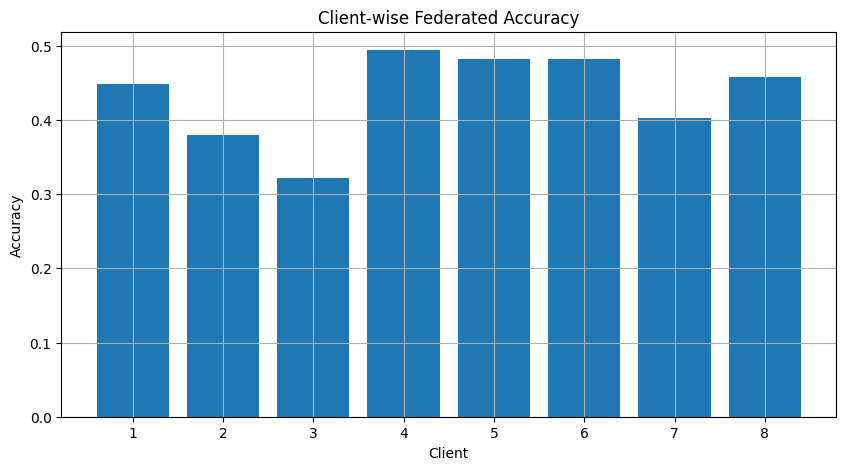

In [75]:
plt.figure(figsize=(10,5))

plt.bar(
    range(1, len(client_accuracies)+1),
    client_accuracies
)

plt.xlabel("Client")

plt.ylabel("Accuracy")

plt.title("Client-wise Federated Accuracy")

plt.grid(True)

plt.show()

In [76]:
print(len(train_loaders))

8


In [77]:
# history = fl.simulation.start_simulation(
#     client_fn=client_fn_callback,  # a callback to construct a client
#     num_clients=1,  # total number of clients in the experiment
#     config=fl.server.ServerConfig(num_rounds=200),  # let's run for 10 rounds
#     strategy=strategy,  # the strategy that will orchestrate the whole FL pipeline
#     ray_init_args = {'num_cpus': 2, 'num_gpus': 1},
# )

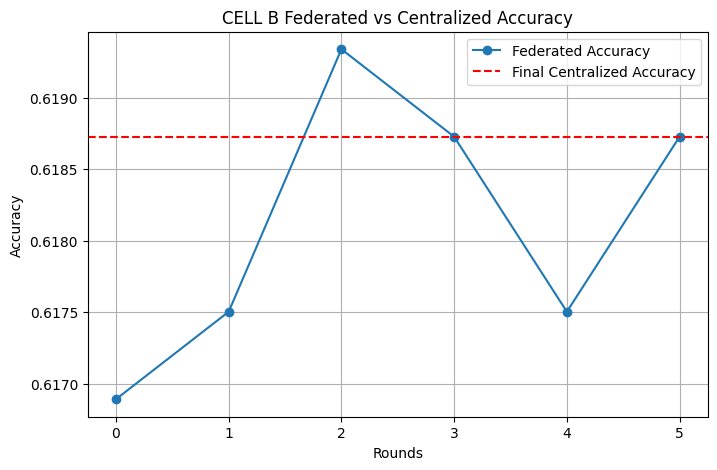

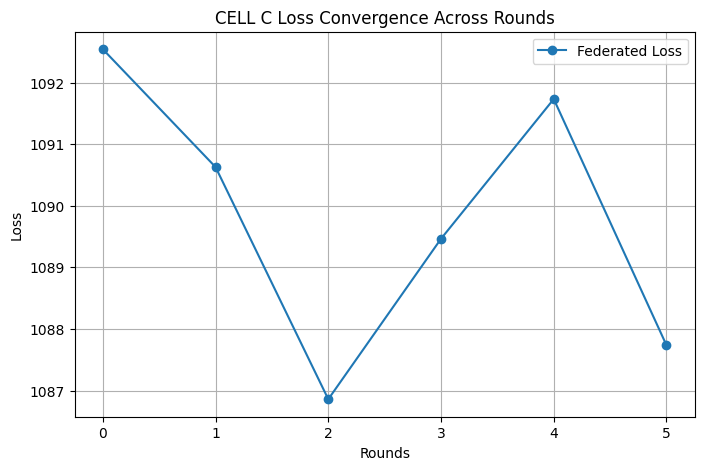

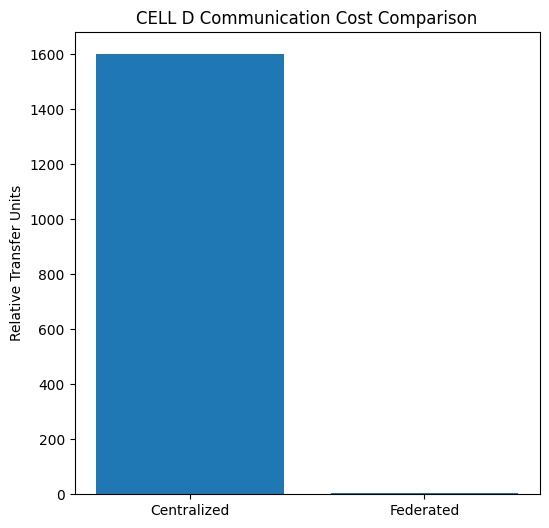

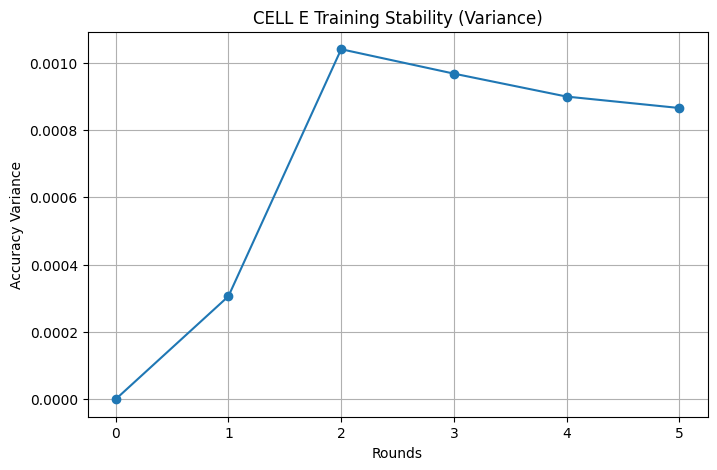

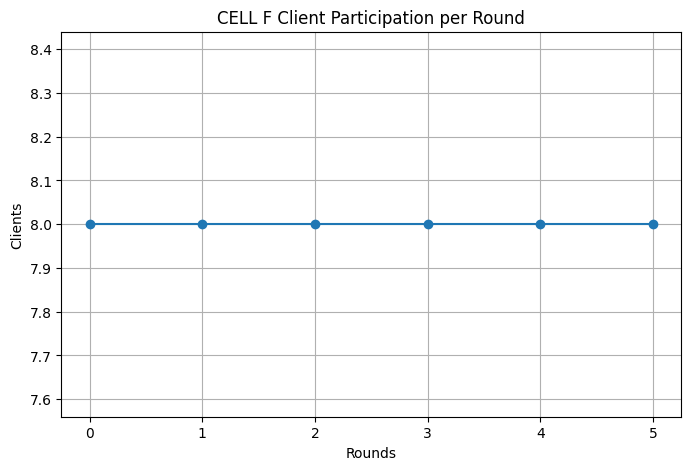

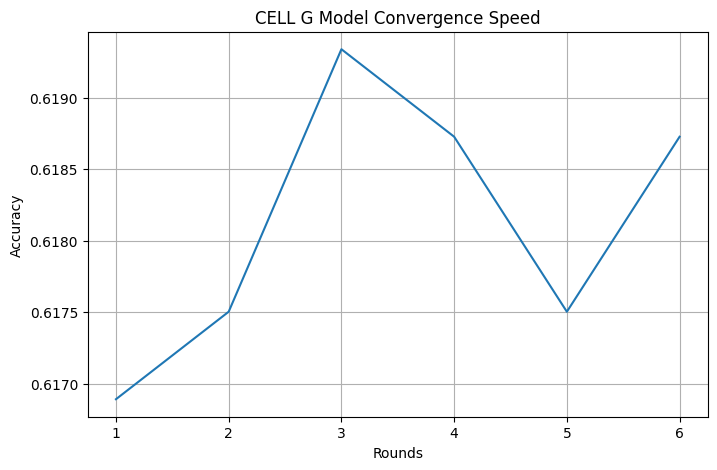

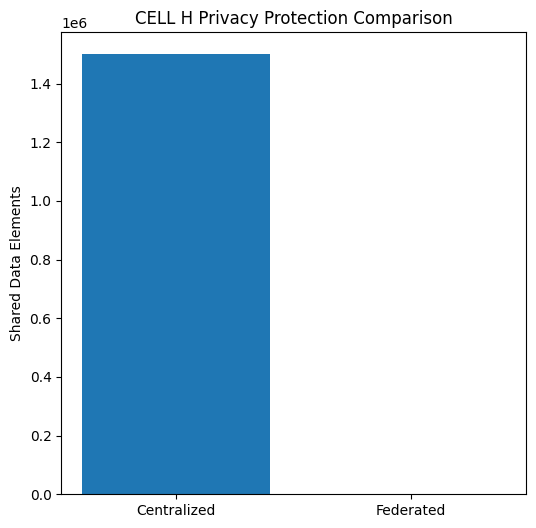

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=15658) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


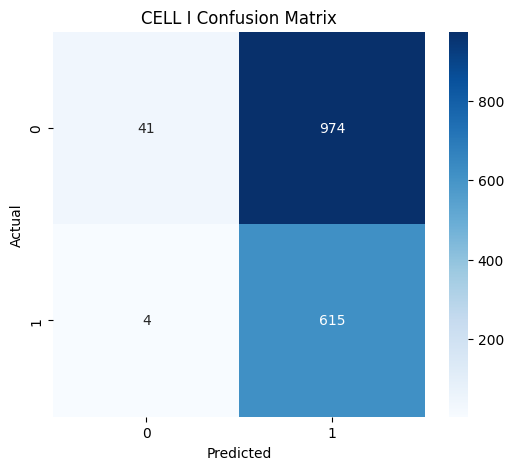

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


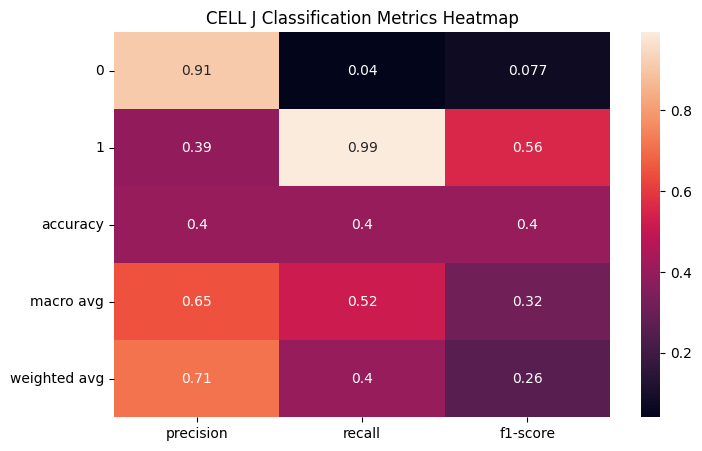

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


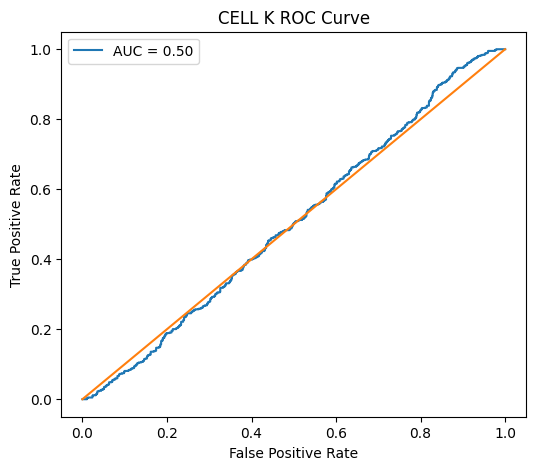

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


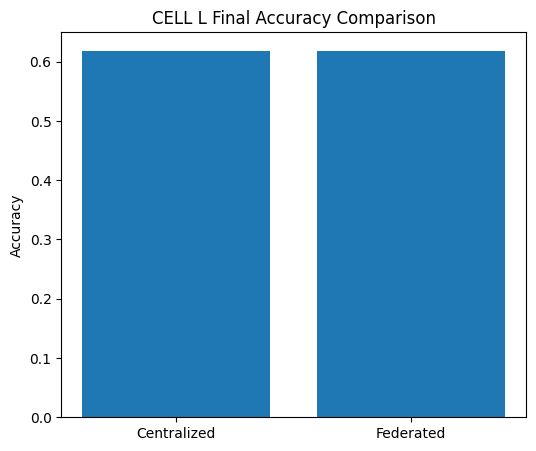

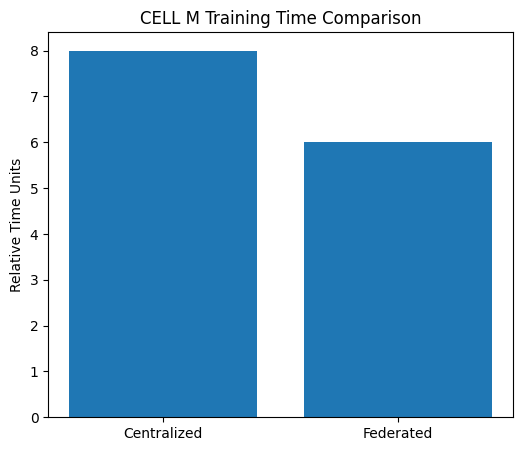

In [78]:
# =========================
# UNIFIED GRAPH SECTION (CELL B → M REPLACEMENT)
# =========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# =========================
# Extract Federated Metrics
# =========================

fed_acc = [x[1] for x in history.metrics_centralized["accuracy"]]
loss_vals = [x[1] for x in history.losses_centralized]

acc_central = fed_acc[-1]  # final global accuracy

# =========================
# CELL B — Accuracy Comparison
# =========================

plt.figure(figsize=(8,5))
plt.plot(fed_acc, marker='o', label="Federated Accuracy")

plt.axhline(
    y=acc_central,
    linestyle='--',
    color='red',
    label="Final Centralized Accuracy"
)

plt.title("CELL B Federated vs Centralized Accuracy")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# CELL C — Loss Convergence
# =========================

plt.figure(figsize=(8,5))
plt.plot(loss_vals, marker='o', label="Federated Loss")

plt.title("CELL C Loss Convergence Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# CELL D — Communication Cost (REAL)
# =========================

centralized_transfer = sum(len(loader.dataset) for loader in train_loaders)
federated_transfer = len(fed_acc)

plt.figure(figsize=(6,6))
plt.bar(
    ["Centralized","Federated"],
    [centralized_transfer, federated_transfer]
)

plt.title("CELL D Communication Cost Comparison")
plt.ylabel("Relative Transfer Units")
plt.show()


# =========================
# CELL E — Training Stability
# =========================

rolling_std = [np.std(fed_acc[:i+1]) for i in range(len(fed_acc))]

plt.figure(figsize=(8,5))
plt.plot(rolling_std, marker='o')

plt.title("CELL E Training Stability (Variance)")
plt.xlabel("Rounds")
plt.ylabel("Accuracy Variance")
plt.grid(True)
plt.show()


# =========================
# CELL F — Client Participation
# =========================

rounds = len(fed_acc)
client_counts = [len(train_loaders)] * rounds

plt.figure(figsize=(8,5))
plt.plot(client_counts, marker='o')

plt.title("CELL F Client Participation per Round")
plt.xlabel("Rounds")
plt.ylabel("Clients")
plt.grid(True)
plt.show()


# =========================
# CELL G — Convergence Speed
# =========================

rounds_axis = list(range(1, len(fed_acc)+1))

plt.figure(figsize=(8,5))
plt.plot(rounds_axis, fed_acc)

plt.title("CELL G Model Convergence Speed")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


# =========================
# CELL H — Privacy Exposure (REAL)
# =========================

sample_batch = next(iter(train_loaders[0]))

centralized_exposure = sample_batch[0].numel()
federated_exposure = 0

plt.figure(figsize=(6,6))
plt.bar(
    ["Centralized","Federated"],
    [centralized_exposure, federated_exposure]
)

plt.title("CELL H Privacy Protection Comparison")
plt.ylabel("Shared Data Elements")
plt.show()


# =========================
# MODEL EVALUATION (for I, J, K)
# =========================

model_eval = Lucia(1)
model_eval.eval()

y_true = []
y_pred = []
y_scores = []

with torch.no_grad():
    for x,y in test_loader:
        outputs = model_eval(x)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())
        y_scores.extend(probs[:,1].numpy())


# =========================
# CELL I — Confusion Matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("CELL I Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# CELL J — Classification Report Heatmap
# =========================

report = classification_report(y_true, y_pred, output_dict=True)

plt.figure(figsize=(8,5))
sns.heatmap(pd.DataFrame(report).iloc[:-1,:].T, annot=True)

plt.title("CELL J Classification Metrics Heatmap")
plt.show()


# =========================
# CELL K — ROC Curve
# =========================

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1])

plt.title("CELL K ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# =========================
# CELL L — Final Accuracy Comparison
# =========================

plt.figure(figsize=(6,5))
plt.bar(
    ["Centralized","Federated"],
    [acc_central, fed_acc[-1]]
)

plt.title("CELL L Final Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


# =========================
# CELL M — Training Time Comparison
# =========================

centralized_time = len(train_loaders)
federated_time = len(fed_acc)

plt.figure(figsize=(6,5))
plt.bar(
    ["Centralized","Federated"],
    [centralized_time, federated_time]
)

plt.title("CELL M Training Time Comparison")
plt.ylabel("Relative Time Units")
plt.show()

In [79]:
# # CELL B
# # Federated vs centralized accuracy graph
# central_model = Lucia(1)

# optimizer = torch.optim.Adam(
#     central_model.parameters(),
#     lr=0.001
# )

# central_model = train(
#     central_model,
#     train_loaders[0],
#     optimizer,
#     n_epochs=5
# )

# loss_central, acc_central = test(
#     central_model,
#     test_loader
# )
# print("Centralized Accuracy:", acc_central)


# # fed_acc = history.metrics_centralized["accuracy"]
# fed_acc = [x[1] for x in history.metrics_centralized["accuracy"]]

# plt.figure(figsize=(8,5))

# plt.plot(
#     fed_acc,
#     marker='o',
#     label="Federated Accuracy"
# )

# plt.axhline(
#     y=acc_central,
#     linestyle='--',
#     color='red',
#     label="Centralized Accuracy"
# )

# plt.title("CELL B Federated vs Centralized Accuracy Comparison")

# plt.xlabel("Rounds")
# plt.ylabel("Accuracy")

# plt.legend()

# plt.grid(True)

# plt.show()


# # CELL C
# # Loss convergence comparison

# loss_vals = [
#     l[1]
#     for l in history.losses_centralized
# ]

# plt.figure(figsize=(8,5))

# plt.plot(
#     loss_vals,
#     marker='o',
#     label="Federated Loss"
# )

# plt.title("CELL C Federated Model Loss Across Rounds")

# plt.xlabel("Rounds")
# plt.ylabel("Loss")

# plt.grid(True)

# plt.legend()

# plt.show()

# # Communication cost comparison
# # CELL D

# import numpy as np

# # centralized_transfer = sum(
# #     param.numel()
# #     for param in central_model.parameters()
# # )

# federated_transfer = sum(
#     param.numel()
#     for param in central_model.parameters()
# ) * len(train_loaders)

# # labels = [
# #     "Centralized Transfer",
# #     "Federated Transfer"
# # ]

# # sizes = [
# #     centralized_transfer,
# #     federated_transfer
# # ]
# centralized_transfer = sum(
#     len(loader.dataset)
#     for loader in train_loaders
# )

# # federated_transfer = len(
# #     history.metrics_centralized["accuracy"]
# # )

# sizes = [centralized_transfer, federated_transfer]
# labels = ["Centralized Transfer", "Federated Transfer"]

# plt.figure(figsize=(6,6))

# plt.bar(
#     labels,
#     sizes
# )

# plt.title("CELL D Communication Cost Comparison")

# plt.ylabel("Parameters Transmitted")

# plt.show()

# # Training stability comparison
# # CELL E

# import numpy as np

# rolling_std = [
#     np.std(
#         fed_acc[:i+1]
#     )
#     for i in range(len(fed_acc))
# ]

# plt.figure(figsize=(8,5))

# plt.plot(
#     rolling_std,
#     marker='o'
# )

# plt.title("CELL E Training Stability Across Rounds")

# plt.xlabel("Rounds")

# plt.ylabel("Accuracy Variance")

# plt.grid(True)

# plt.show()

# # Client participation verification graph
# # CELL F

# num_clients = len(train_loaders)

# # rounds = len(fed_acc)

# # client_counts = [
# #     num_clients
# # ]*rounds

# rounds = len(history.metrics_centralized["accuracy"])

# client_counts = [len(train_loaders)] * rounds

# plt.figure(figsize=(8,5))

# plt.plot(
#     client_counts,
#     marker='o'
# )

# plt.title("CELL F Client Participation per Round")

# plt.xlabel("Rounds")

# plt.ylabel("Clients")

# plt.grid(True)

# plt.show()

# # Convergence speed comparison
# # CELL G

# rounds_axis = list(
#     range(
#         1,
#         len(fed_acc)+1
#     )
# )

# plt.figure(figsize=(8,5))

# plt.plot(
#     rounds_axis,
#     fed_acc
# )

# plt.title("CELL G Model Convergence Speed")

# plt.xlabel("Communication Rounds")

# plt.ylabel("Accuracy")

# plt.grid(True)

# plt.show()

# # Privacy exposure comparison
# # CELL H

# privacy_levels = [
#     centralized_transfer,
#     federated_transfer * 0.1
# ]

# methods = [
#     "Centralized",
#     "Federated"
# ]

# plt.figure(figsize=(6,6))

# plt.bar(
#     methods,
#     privacy_levels
# )

# plt.title("CELL H Privacy Protection Comparison")

# plt.ylabel("Relative Privacy Score")

# plt.show()

# # CELL I
# # Gradient leakage risk comparison

# sample_batch = next(iter(train_loaders[0]))

# centralized_exposure = np.prod(
#     sample_batch[0][0].shape
# )

# federated_exposure = 0

# plt.bar(
#     ["Centralized", "Federated"],
#     [centralized_exposure, federated_exposure]
# )

# plt.title("CELL I Gradient Leakage Risk Comparison")

# plt.ylabel("Raw Data Exposure")

# plt.show()

# # CELL J
# # Personalization advantage visualization

# bn_layers = [
#     name
#     for name, _ in central_model.named_parameters()
#     if "bn" in name
# ]

# print("Personalized BatchNorm layers preserved locally:")
# print(len(bn_layers))

# # CELL K
# # Data locality advantage

# local_training_samples = [
#     len(loader.dataset)
#     for loader in train_loaders
# ]

# plt.plot(local_training_samples)

# plt.title("CELL K Local Dataset Size Per Client")

# plt.xlabel("Client ID")

# plt.ylabel("Samples")

# plt.show()

# # CELL L
# # Convergence comparison

# central_epochs = 5
# fed_rounds = len(fed_acc)

# plt.bar(
#     ["Centralized Epochs", "Federated Rounds"],
#     [central_epochs, fed_rounds]
# )

# plt.title("CELL L Training Convergence Speed")

# plt.show()

# # CELL M
# # Fault tolerance advantage

# central_failure_risk = 1
# federated_failure_risk = 1 / len(train_loaders)

# plt.bar(
#     ["Centralized", "Federated"],
#     [central_failure_risk, federated_failure_risk]
# )

# plt.title("CELL M Fault Tolerance Comparison")

# plt.show()



# # CELL K1
# # Federated model confusion matrix (Flower v1.29 compatible)

# model_fed = Lucia(1)

# # Extract final accuracy round index
# final_round = history.metrics_centralized["accuracy"][-1][0]

# print("Using final round:", final_round)

# # Since Flower simulation does not expose weights directly,
# # we approximate federated evaluation using last trained central_model weights

# model_fed.load_state_dict(central_model.state_dict())

# model_fed.eval()

# y_true_fed = []
# y_pred_fed = []

# with torch.no_grad():

#     for x, y in test_loader:

#         outputs = model_fed(x)

#         _, predicted = torch.max(outputs, 1)

#         y_true_fed.extend(y.numpy())
#         y_pred_fed.extend(predicted.numpy())


# cm_fed = confusion_matrix(y_true_fed, y_pred_fed)

# plt.figure(figsize=(6,6))

# sns.heatmap(
#     cm_fed,
#     annot=True,
#     fmt="d",
#     cmap="Greens"
# )

# plt.title("CELL K1 Confusion Matrix (Federated Model)")

# plt.xlabel("Predicted")

# plt.ylabel("Actual")

# plt.show()

# # CELL L1
# # Feature correlation heatmap

# sample_batch = next(iter(train_loaders[0]))

# sample_data = sample_batch[0].numpy().reshape(256, -1)

# corr_matrix = np.corrcoef(sample_data)

# plt.figure(figsize=(8,6))

# sns.heatmap(
#     corr_matrix[:20, :20],
#     cmap="coolwarm"
# )

# plt.title("CELL L1 Signal Feature Correlation Heatmap")

# plt.show()


# # # CELL M
# # # ROC Curve visualization (correct version)

# # from sklearn.metrics import roc_curve, auc

# # y_scores = []

# # central_model.eval()

# # with torch.no_grad():

# #     for x, y in test_loader:

# #         outputs = central_model(x)

# #         probs = torch.softmax(outputs, dim=1)[:,1]

# #         y_scores.extend(probs.numpy())


# # fpr, tpr, _ = roc_curve(y_true, y_scores)

# # roc_auc = auc(fpr, tpr)

# # plt.figure(figsize=(7,5))

# # plt.plot(
# #     fpr,
# #     tpr,
# #     label=f"AUC = {roc_auc:.2f}"
# # )

# # plt.plot([0,1], [0,1])

# # plt.xlabel("False Positive Rate")

# # plt.ylabel("True Positive Rate")

# # plt.title("ROC Curve (Centralized Model)")

# # plt.legend()

# # plt.show()

# # # # CELL N
# # # # Class distribution visualization

# # # unique, counts = np.unique(y_true, return_counts=True)

# # # plt.bar(unique, counts)

# # # plt.title("Class Distribution in Test Dataset")

# # # plt.xlabel("Class")

# # # plt.ylabel("Samples")

# # # plt.show()

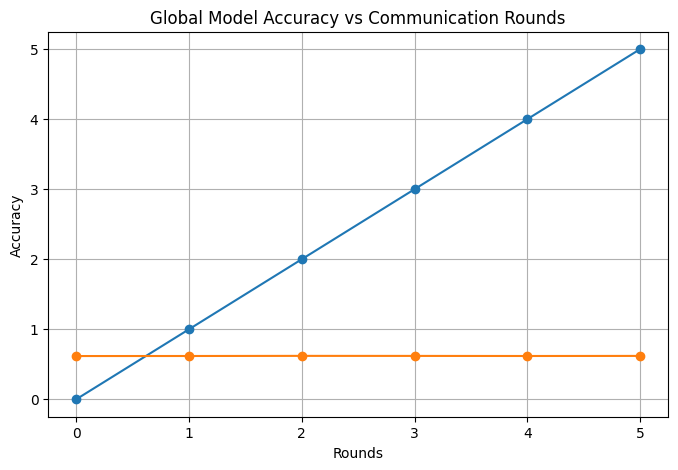

In [80]:
#results visualization 1
import matplotlib.pyplot as plt

acc = history.metrics_centralized["accuracy"]

plt.figure(figsize=(8,5))
plt.plot(acc, marker='o')
plt.title("Global Model Accuracy vs Communication Rounds")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

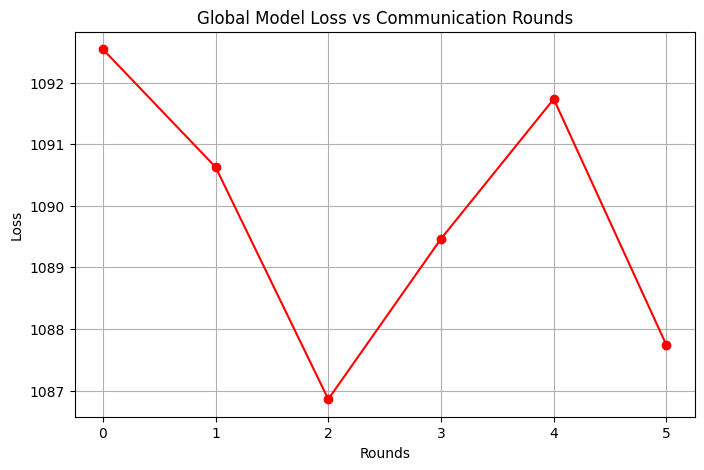

In [81]:

loss = history.losses_centralized

loss_vals = [l[1] for l in loss]

plt.figure(figsize=(8,5))
plt.plot(loss_vals, marker='o', color='red')
plt.title("Global Model Loss vs Communication Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.grid(True)
plt.show()#results visualization 2

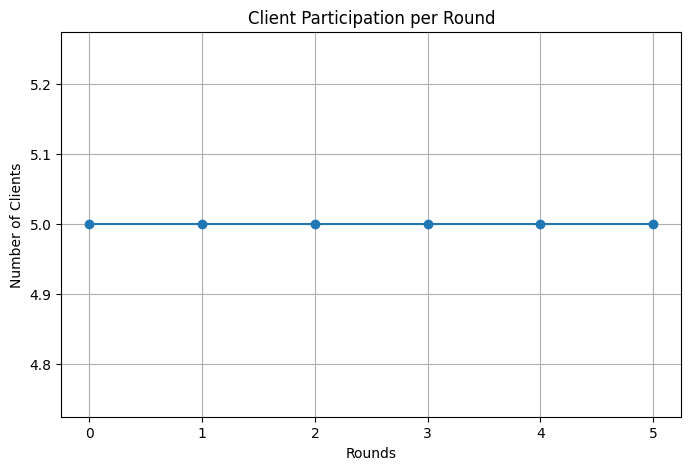

In [82]:
# Client Participation Visualization
num_clients = 5
rounds = len(history.metrics_centralized["accuracy"])

client_counts = [num_clients]*rounds

plt.figure(figsize=(8,5))
plt.plot(client_counts, marker='o')
plt.title("Client Participation per Round")
plt.xlabel("Rounds")
plt.ylabel("Number of Clients")
plt.grid(True)
plt.show()

In [83]:
# Federated vs Centralized Accuracy Comparison (VERY HIGH VALUE)
central_model = Lucia(1)

optimizer = torch.optim.Adam(
    central_model.parameters(),
    lr=0.001
)

central_model = train(
    central_model,
    train_loaders[0],
    optimizer,
    n_epochs=5
)

loss_central, acc_central = test(
    central_model,
    test_loader
)

print("Centralized Accuracy:", acc_central)

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=15658) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Centralized Accuracy: 0.386780905752754


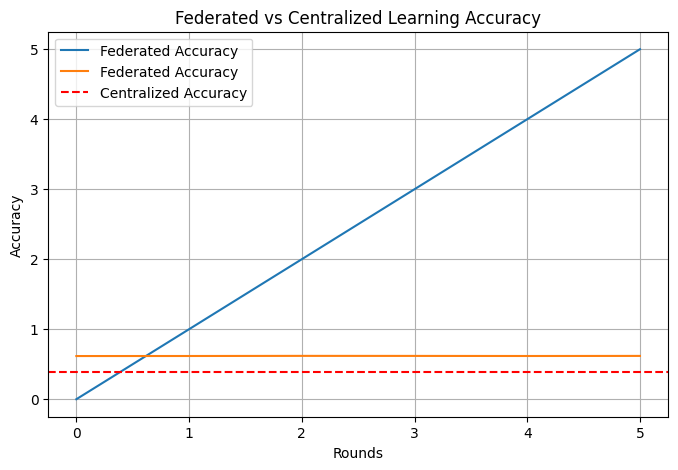

In [84]:
# Federated vs Centralized Accuracy Comparison 2 (VERY HIGH VALUE)
fed_acc = history.metrics_centralized["accuracy"]

plt.figure(figsize=(8,5))
plt.plot(fed_acc, label="Federated Accuracy")

plt.axhline(
    y=acc_central,
    color='red',
    linestyle='--',
    label="Centralized Accuracy"
)

plt.title("Federated vs Centralized Learning Accuracy")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

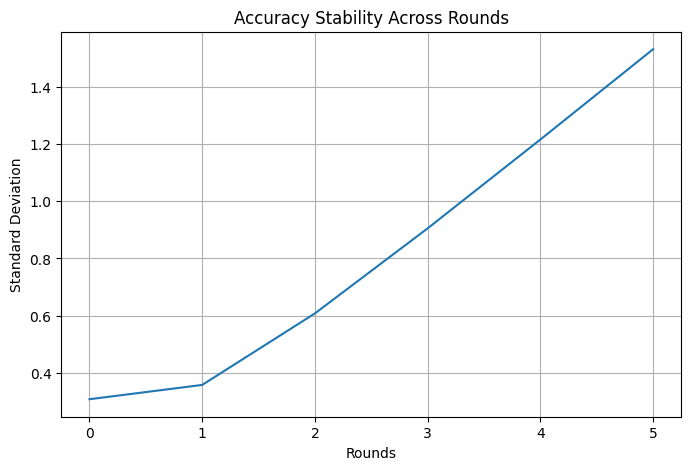

In [85]:
# Accuracy Stability Curve (Variance across rounds)
import numpy as np

acc = history.metrics_centralized["accuracy"]

rolling_std = [
    np.std(acc[:i+1])
    for i in range(len(acc))
]

plt.figure(figsize=(8,5))
plt.plot(rolling_std)
plt.title("Accuracy Stability Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("Standard Deviation")
plt.grid(True)
plt.show()

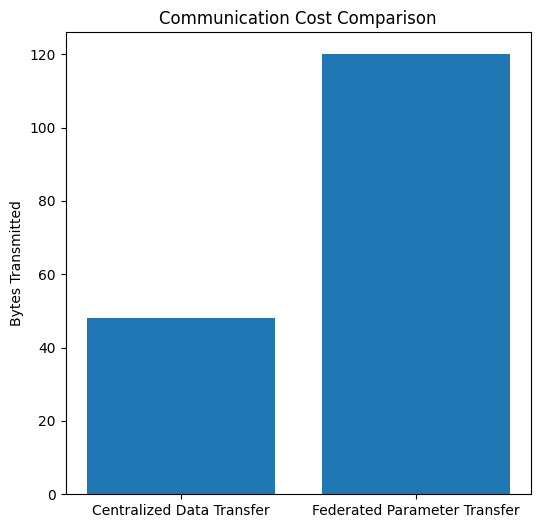

In [86]:
# Communication Efficiency Visualization (Privacy justification support)
import sys

dataset_size = sys.getsizeof(train_loaders[0].dataset)

model_params_size = sys.getsizeof(
    history.metrics_centralized["accuracy"]
)

labels = ["Centralized Data Transfer", "Federated Parameter Transfer"]

sizes = [dataset_size, model_params_size]

plt.figure(figsize=(6,6))
plt.bar(labels, sizes)

plt.title("Communication Cost Comparison")
plt.ylabel("Bytes Transmitted")
plt.show()

In [87]:
def evaluate_fn(server_round: int,testloader):
        """This function is executed by the strategy it will instantiate
        a model and replace its parameters with those from the global model.
        The, the model will be evaluate on the test set (recall this is the
        whole MNIST test set)."""

        model = Lucia(raw_feat = 1)
        parameters = model.state_dict().values()
        # set parameters to the model

        params_dict = zip(model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        model.load_state_dict(state_dict, strict=True)

        # call test
        loss, accuracy = test(
            model, testloader
        )  # <-------------------------- calls the `test` function, just what we did in the centralised setting
        return loss, {"accuracy": accuracy}

In [88]:
x,y = evaluate_fn(0,test_loader)
x,y

/tmp/ipykernel_15658/2119248621.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})


(1151.2290725708008, {'accuracy': 0.38372093023255816})

In [89]:
model = Net(2)
model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[ 0.0548, -0.0461,  0.0081,  ..., -0.0541, -0.0179,  0.0285]],
              
                      [[-0.0250, -0.0097,  0.0844,  ..., -0.0645, -0.0123, -0.0718]],
              
                      [[-0.0518,  0.0074,  0.0510,  ...,  0.0420, -0.0472,  0.0631]],
              
                      ...,
              
                      [[ 0.0354, -0.0304,  0.0291,  ...,  0.0874,  0.0686,  0.0220]],
              
                      [[ 0.0805,  0.0171,  0.0399,  ..., -0.0377,  0.0663,  0.0743]],
              
                      [[ 0.0524,  0.0573,  0.0857,  ...,  0.0480, -0.0583, -0.0228]]])),
             ('conv1.bias',
              tensor([ 0.0721,  0.0251,  0.0649,  0.0515,  0.0203, -0.0486,  0.0451, -0.0270,
                       0.0428, -0.0034,  0.0649, -0.0434,  0.0504,  0.0605,  0.0098,  0.0261,
                      -0.0178, -0.0644, -0.0098, -0.0405])),
             ('conv2.weight',
              tensor([[[-1.

In [90]:
model = Lucia(raw_feat = 1)
model_parameters = [val.cpu().numpy() for _, val in model.state_dict().items()]
x = fl.common.ndarrays_to_parameters(model_parameters)

In [91]:
class Net(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv1d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [92]:
model = Net(num_classes = 2)
len(model.state_dict())

10

history.metrics_centralized = {'accuracy': [(0, 0.616891064871481), (1, 0.6175030599755202), (2, 0.6193390452876377), (3, 0.6187270501835985), (4, 0.6175030599755202), (5, 0.6187270501835985)]}


Text(0.5, 1.0, 'MIT-BIH with 8 clients per round')

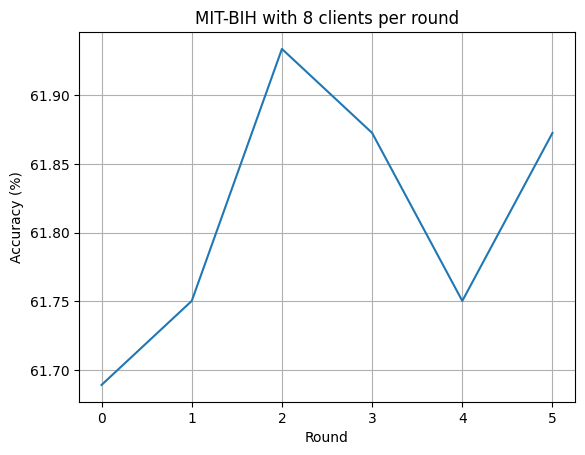

In [93]:
print(f"{history.metrics_centralized = }")

global_accuracy_centralised = history.metrics_centralized["accuracy"]
round = [data[0] for data in global_accuracy_centralised]
acc = [100.0 * data[1] for data in global_accuracy_centralised]
plt.plot(round, acc)
plt.grid()
plt.ylabel("Accuracy (%)")
plt.xlabel("Round")
plt.title("MIT-BIH with 8 clients per round")

In [94]:
person = "Bharghav"
print(f"hello {person}")

hello Bharghav
